# **Bank Fraud Detection — End-to-End ML Pipeline**

**Dataset:** 1,000,000 transactions with 26 features  
**Problem Type:** Binary Classification (Fraud vs. Legitimate)  
**Class Imbalance:** ~5.5% fraud rate
## Pipeline Overview

| Step | Description |
|------|-------------|
| 1 | Exploratory Data Analysis (EDA) |
| 2 | Data Preprocessing & Feature Engineering |
| 3 | Train-Test Split |
| 4 | One-Hot Encoding |
| 5 | SMOTE — Handling Class Imbalance |
| 6 | Model Training (Logistic Regression, Random Forest, XGBoost) |
| 7 | Performance Metrics & Evaluation |


In [1]:
#Core Libraries
import pandas as pd
import numpy as np

#EDA
import matplotlib.pyplot as plt
import seaborn as sns


#Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

#Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier


#Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)

In [2]:
df=pd.read_csv('bank_fraud.csv')

In [3]:
df.shape

(1000000, 26)

In [4]:
df.head()

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21,0,0,USA,London,Grocery,...,39.49,157,23,52.7,10.20,0,0,0,0,NaN
1,TXN0000000002,CUST00146868,2024-02-06,05:16:00,5,0,1,UK,New York,Healthcare,...,153.71,153,23,0.9,12.47,0,0,0,0,NaN
2,TXN0000000003,CUST00131933,2024-06-28,12:15:00,12,0,0,Canada,Delhi,Grocery,...,118.20,161,20,9.2,0.08,0,1,0,0,NaN
3,TXN0000000004,CUST00103695,2023-03-16,02:53:00,2,0,1,France,Tokyo,Utilities,...,49.50,160,25,14.8,17.94,1,0,1,1,Synthetic Identity
4,TXN0000000005,CUST00119880,2024-07-12,12:39:00,12,0,0,Canada,Melbourne,Clothing,...,30.74,134,18,38.9,2.16,0,0,0,0,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 26 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   transaction_id            1000000 non-null  object 
 1   customer_id               1000000 non-null  object 
 2   transaction_date          1000000 non-null  object 
 3   transaction_time          1000000 non-null  object 
 4   hour_of_day               1000000 non-null  int64  
 5   is_weekend                1000000 non-null  int64  
 6   is_night_transaction      1000000 non-null  int64  
 7   country                   1000000 non-null  object 
 8   city                      1000000 non-null  object 
 9   merchant_category         1000000 non-null  object 
 10  payment_method            1000000 non-null  object 
 11  device_type               1000000 non-null  object 
 12  customer_age              1000000 non-null  int64  
 13  credit_score              10

In [6]:
df.isnull().sum()

transaction_id                   0
customer_id                      0
transaction_date                 0
transaction_time                 0
hour_of_day                      0
is_weekend                       0
is_night_transaction             0
country                          0
city                             0
merchant_category                0
payment_method                   0
device_type                      0
customer_age                     0
credit_score                     0
account_age_years                0
account_balance                  0
transaction_amount               0
num_prev_transactions            0
transaction_freq_monthly         0
distance_from_home_km            0
time_since_last_txn_hrs          0
is_international                 0
failed_attempts                  0
pin_changed_recently             0
is_fraud                         0
fraud_type                  944745
dtype: int64

In [7]:
df.nunique()

transaction_id              1000000
customer_id                  198662
transaction_date               1826
transaction_time               1440
hour_of_day                      24
is_weekend                        2
is_night_transaction              2
country                          10
city                             20
merchant_category                15
payment_method                    6
device_type                       5
customer_age                     68
credit_score                    509
account_age_years               300
account_balance              828209
transaction_amount           114727
num_prev_transactions           114
transaction_freq_monthly         43
distance_from_home_km          1814
time_since_last_txn_hrs        8798
is_international                  2
failed_attempts                   6
pin_changed_recently              2
is_fraud                          2
fraud_type                        6
dtype: int64

In [8]:
df = df.drop(columns=['transaction_id', 'customer_id', 'transaction_date','transaction_time', 'fraud_type'])

In [9]:
fraud_counts=df['is_fraud'].value_counts()

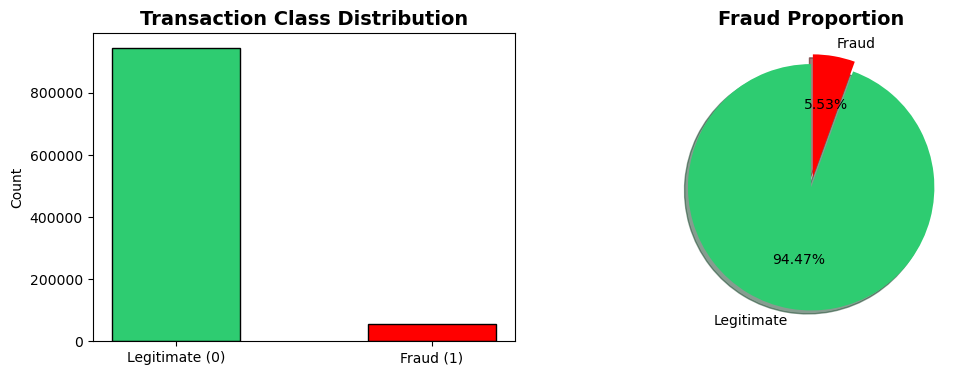

In [10]:
#Class Distribution -------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#Plotting bars-------------------------
bars = axes[0].bar(['Legitimate (0)', 'Fraud (1)'], fraud_counts,
                   color=['#2ecc71', '#ff0000'], edgecolor='black', width=0.5)
axes[0].set_title('Transaction Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

#PLotting Pie Chart-------------------
axes[1].pie(fraud_counts, labels=['Legitimate', 'Fraud'],
            colors=['#2ecc71', '#ff0000'], autopct='%1.2f%%',
            startangle=90, explode=(0, 0.08), shadow=True)
axes[1].set_title('Fraud Proportion', fontsize=14, fontweight='bold')


plt.show()

In [11]:
print(f' Class Imbalance Ratio  →  {fraud_counts[0]/fraud_counts[1]:.1f}:1  (Legitimate vs Fraud)')

 Class Imbalance Ratio  →  17.1:1  (Legitimate vs Fraud)


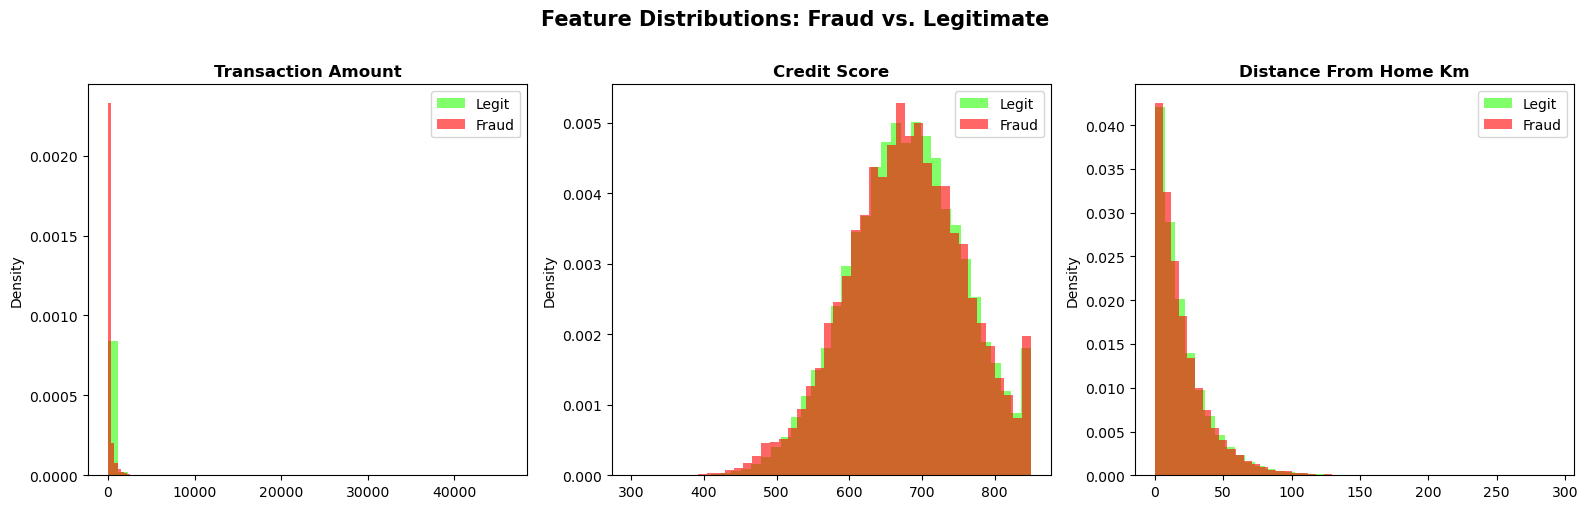

In [12]:
#Targetting Numerical Features
key_features = ['transaction_amount', 'credit_score', 'distance_from_home_km']

fig, axes = plt.subplots(1, 3,figsize=(16, 5))
axes = axes.flatten()

for ax, feat in zip(axes, key_features):
    for label, color in zip([0, 1], ['#2eff07', '#ff0000']):
        subset = df[df['is_fraud'] == label][feat].dropna()
        ax.hist(subset, bins=40, alpha=0.6, color=color,
                label='Legit' if label == 0 else 'Fraud', density=True)
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.legend()
    ax.set_ylabel('Density')

plt.suptitle('Feature Distributions: Fraud vs. Legitimate', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()

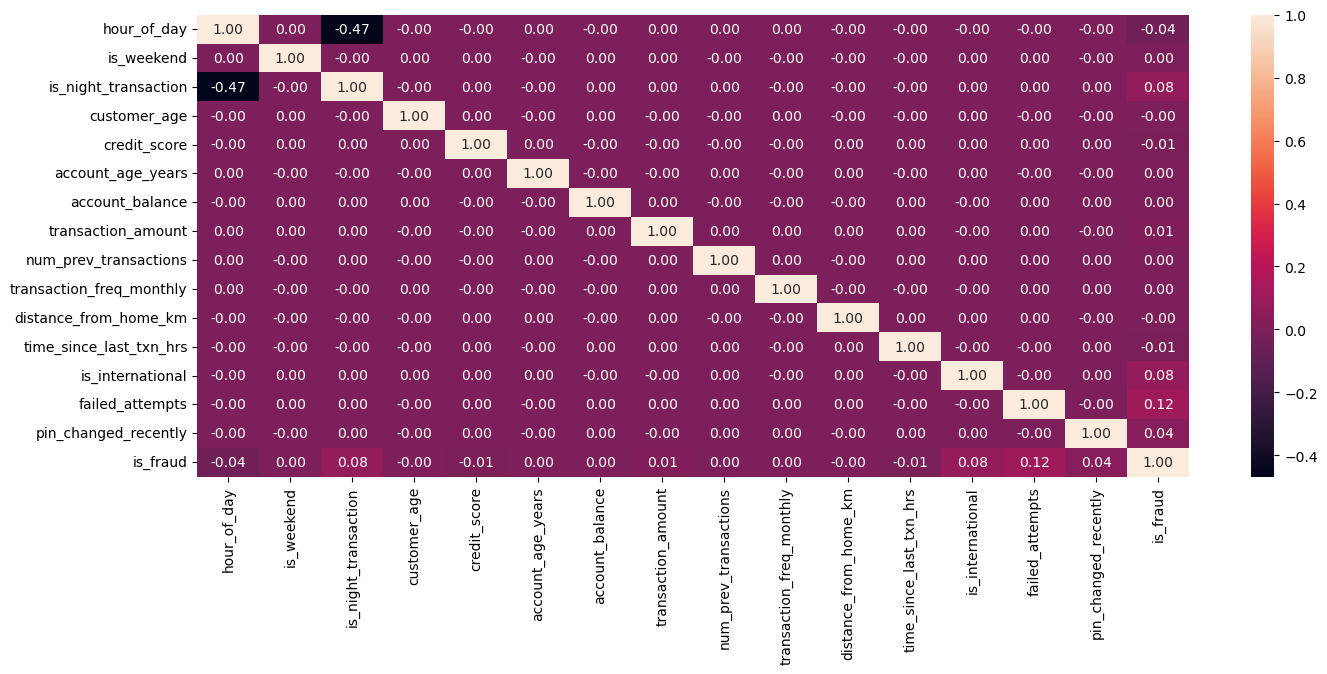

In [13]:
#Correlation Heatmap for Numerical Columns
plt.figure(figsize=(16, 6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            #cmap='seismic',
            fmt='.2f')

plt.show()

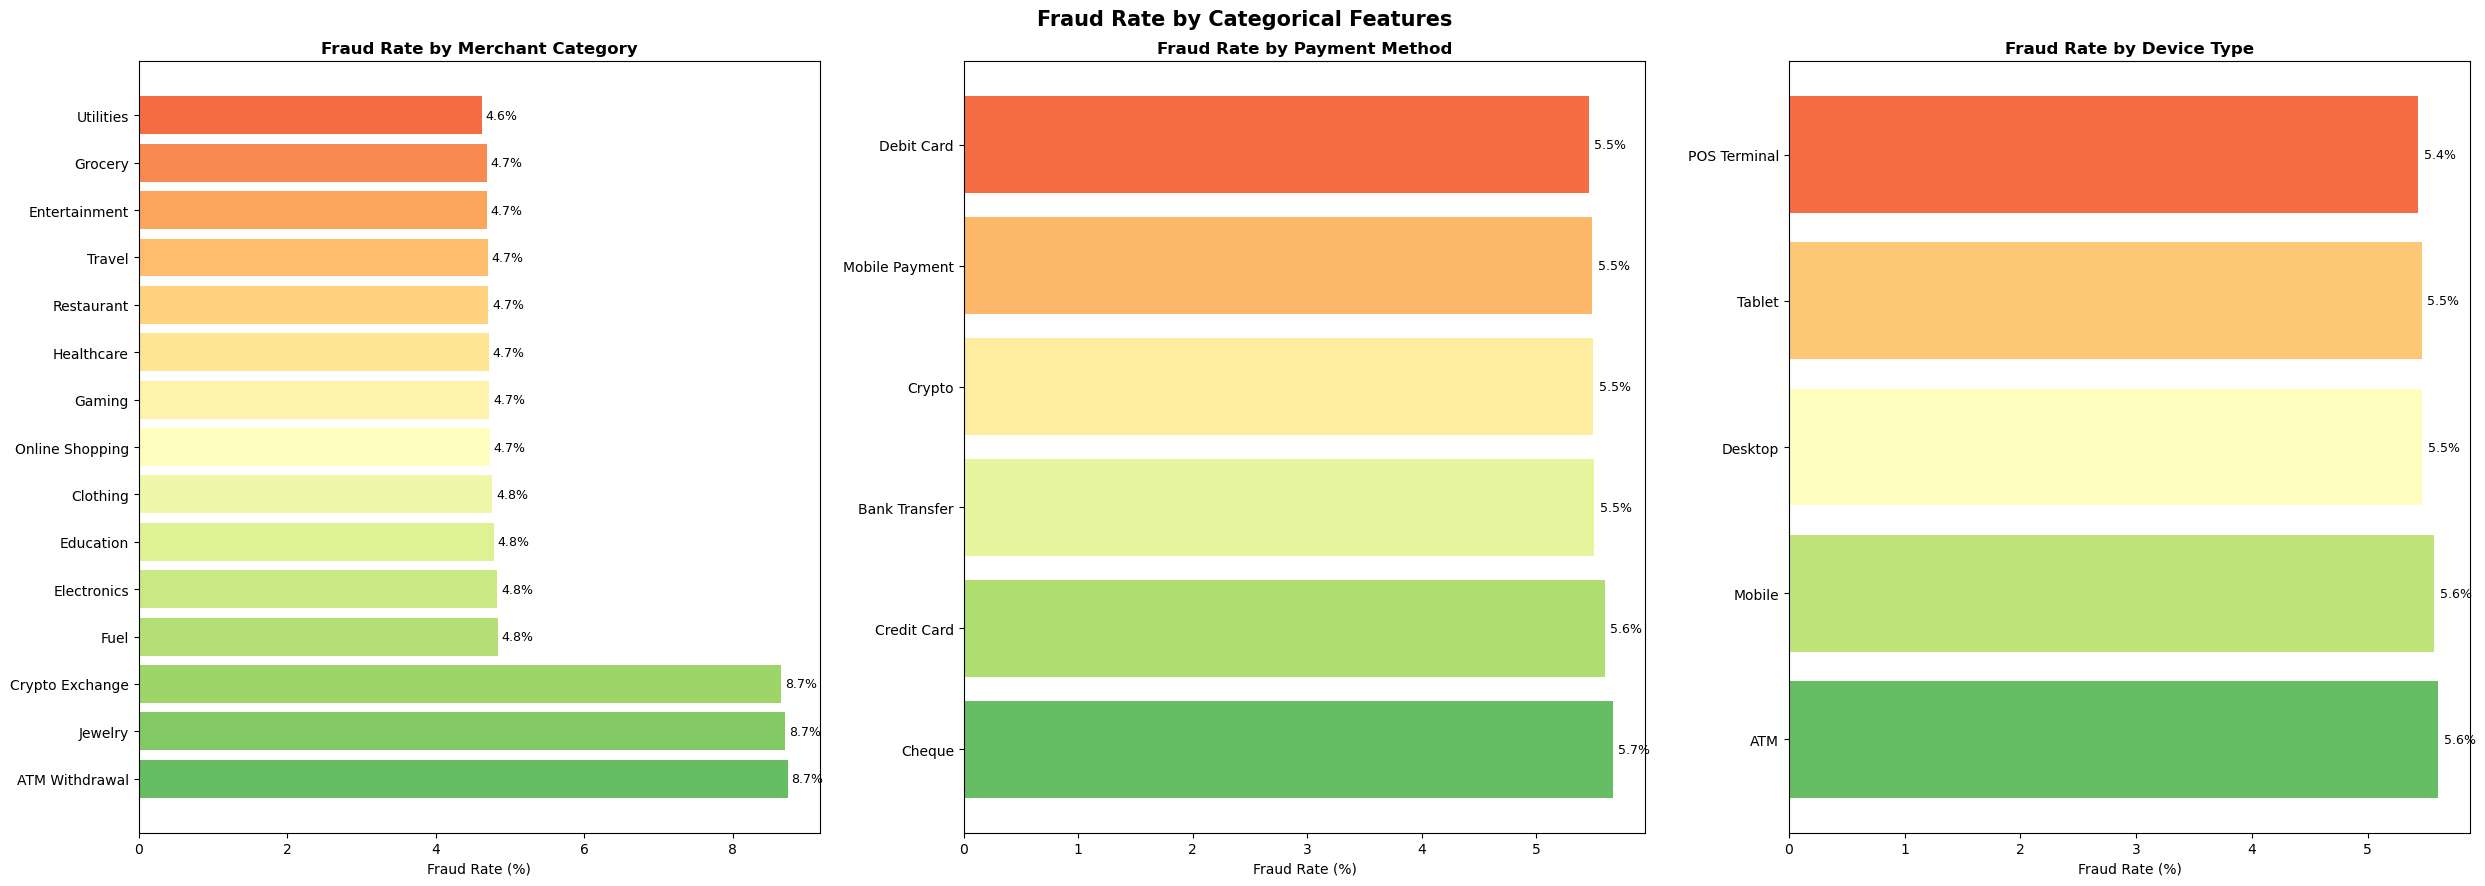

In [14]:
# Targetting Categorical Columns
cat_cols = [ 'merchant_category', 'payment_method', 'device_type']

fig, axes = plt.subplots(1, 3, figsize=(25, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    fraud_rate = df.groupby(col)['is_fraud'].mean().sort_values(ascending=False) * 100
    bars = ax.barh(fraud_rate.index, fraud_rate.values,
                   color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(fraud_rate))))
    ax.set_title(f'Fraud Rate by {col.replace("_", " ").title()}', fontweight='bold')
    ax.set_xlabel('Fraud Rate (%)')
    for bar, val in zip(bars, fraud_rate.values):
        ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Fraud Rate by Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_fraud_rates.png', bbox_inches='tight')
plt.show()

In [15]:
X=df.drop(columns='is_fraud')
y=df['is_fraud']

In [16]:
categorical_cols  = X.select_dtypes(include='object').columns.tolist()
numerical_cols   = X.select_dtypes(include=np.number).columns.tolist()

In [17]:
from sklearn.model_selection import train_test_split, StratifiedKFold

#Here we use Startified K-fold to preserve the fraud ratio in both train and test splits by stratify=y 

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y         
)

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('scaler', StandardScaler(),numerical_cols)
    ],
    remainder='passthrough'
)


X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)


ohe_features  = preprocessor.named_transformers_['ohe'].get_feature_names_out(categorical_cols)
all_features  = np.concatenate([ohe_features,numerical_cols])

In [19]:
# ── Apply SMOTE to training set ONLY ─────────────────────────────────────────
smote = SMOTE(sampling_strategy=0.3, random_state=42, n_jobs=-1)
# sampling_strategy=0.3 → upsample fraud to 30% of majority class

X_train_sm, y_train_sm = smote.fit_resample(X_train_enc, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\imblearn\over_sampling\_smote\base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(


In [20]:
#Model Registry
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=500, C=1.0, class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, class_weight='balanced',
        n_jobs=-1, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        scale_pos_weight=1,           # data already balanced via SMOTE
        use_label_encoder=False, eval_metric='logloss',
        n_jobs=-1, random_state=42
    )
}

In [21]:
#Model Training
trained_models = {}
for name, model in models.items():
    print(f' Training {name}...', end=' ')
   
    model.fit(X_train_sm, y_train_sm)
    
    trained_models[name] = model
    print(f'Done for {name}')

 Training Logistic Regression... Done for Logistic Regression
 Training Random Forest... Done for Random Forest
 Training XGBoost... 

C:\Users\Areesh Arafat\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [03:49:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Done for XGBoost


In [22]:
#Results
results = []

for name, model in trained_models.items():
    y_pred      = model.predict(X_test_enc)
    y_prob      = model.predict_proba(X_test_enc)[:, 1]

    results.append({
        'Model'        : name,
        'Accuracy'     : accuracy_score(y_test, y_pred),
        'Precision'    : precision_score(y_test, y_pred),
        'Recall'       : recall_score(y_test, y_pred),
        'F1-Score'     : f1_score(y_test, y_pred),
        'ROC-AUC'      : roc_auc_score(y_test, y_prob),
        'PR-AUC'       : average_precision_score(y_test, y_prob),
    })

metrics_df = pd.DataFrame(results).set_index('Model')

In [23]:
#Detailed Comparison
best_model_name = metrics_df['F1-Score'].idxmax()
best_model      = trained_models[best_model_name]
y_pred_best     = best_model.predict(X_test_enc)

print(f'🏆 Best Model: {best_model_name}\n')
print(classification_report(y_test, y_pred_best,
                             target_names=['Legitimate', 'Fraud']))

🏆 Best Model: Random Forest

              precision    recall  f1-score   support

  Legitimate       0.96      0.86      0.91    188949
       Fraud       0.13      0.35      0.19     11051

    accuracy                           0.83    200000
   macro avg       0.54      0.61      0.55    200000
weighted avg       0.91      0.83      0.87    200000



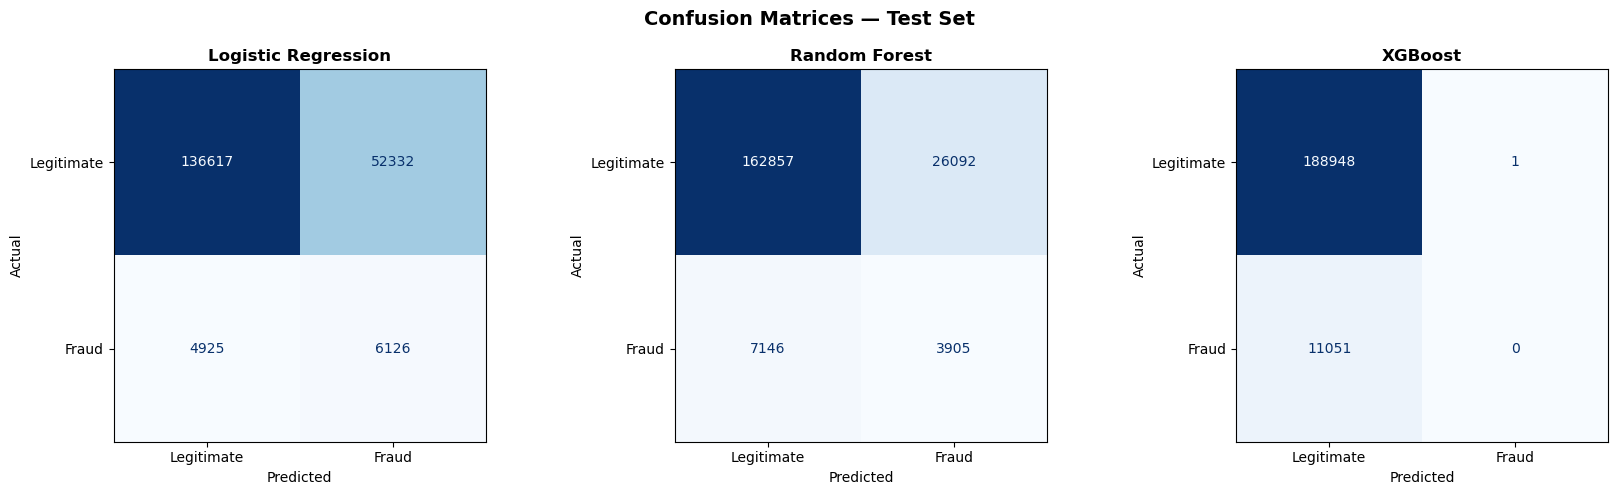

In [24]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_enc)
    cm     = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=['Legitimate', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

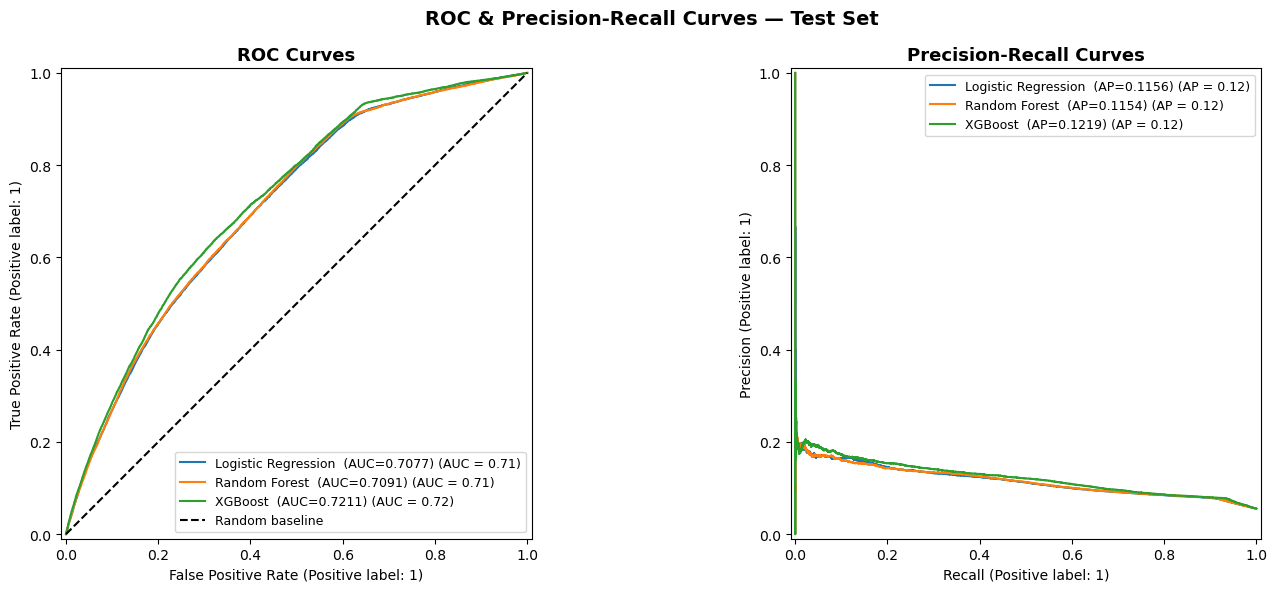

In [25]:
#ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test_enc)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    RocCurveDisplay.from_predictions(
        y_test, y_prob, name=f'{name}  (AUC={auc:.4f})', ax=axes[0]
    )
axes[0].plot([0, 1], [0, 1], 'k--', label='Random baseline')
axes[0].set_title('ROC Curves', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)

# Precision-Recall Curve
for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test_enc)[:, 1]
    ap     = average_precision_score(y_test, y_prob)
    PrecisionRecallDisplay.from_predictions(
        y_test, y_prob, name=f'{name}  (AP={ap:.4f})', ax=axes[1]
    )
axes[1].set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('ROC & Precision-Recall Curves — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_pr_curves.png', bbox_inches='tight')
plt.show()